<a href="https://colab.research.google.com/github/anix07/PYTHON-FOR-DATA-ANALYSIS/blob/main/Onetime_Sales_%26Marketing_LTD_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('Sales Data_PDA_4052 csv.csv', encoding='latin-1')
print(df.shape)
print(df.head())

(1001, 7)
   order_id customer_id sales_person  priority ship_mode        date  \
0      8999        C406        Kelly      High     Plane  12/06/2020   
1     47872        C100        Kelly  Critical     Plane  12/06/2020   
2     29988        C006        Kelly      High     Lorry  12/06/2020   
3     37348        C492        Kelly      High     Plane  13/06/2020   
4     28001        C231        Kelly  Critical     Plane  14/06/2020   

     value_£  
0  £1,553.44  
1    £315.40  
2  £5,075.89  
3    £520.67  
4  £8,431.37  


In [ ]:
print(df.isnull().sum())

order_id        0
customer_id     0
sales_person    0
priority        0
ship_mode       0
date            0
value_£         0
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.dtypes)

order_id         int64
customer_id     object
sales_person    object
priority        object
ship_mode       object
date            object
value_£         object
dtype: object


In [ ]:
df['value_£'] = df['value_£'].astype(str).str.replace('£', '', regex=False)
df['value_£'] = df['value_£'].astype(str).str.replace(',', '', regex=False)
df['value_£'] = pd.to_numeric(df['value_£'], errors='coerce')


In [ ]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [ ]:
df['sales_person'] = df['sales_person'].astype('category')
df['priority']     = df['priority'].astype('category')
df['ship_mode']    = df['ship_mode'].astype('category')

In [ ]:
print(df.dtypes)

order_id                 int64
customer_id             object
sales_person          category
priority              category
ship_mode             category
date            datetime64[ns]
value_£                float64
dtype: object


In [ ]:
print(df['value_£'].describe())
print(f"Skewness: {df['value_£'].skew():.2f}")
print(f"Kurtosis: {df['value_£'].kurt():.2f}")

count     1001.000000
mean      1778.402248
std       3457.457206
min          2.450000
25%        134.400000
50%        417.580000
75%       1816.930000
max      27448.240000
Name: value_£, dtype: float64
Skewness: 3.77
Kurtosis: 17.42


In [ ]:
print(df.groupby('sales_person', observed=True)['value_£']
        .agg(count='count', total='sum', mean='mean', median='median', std='std').round(2))

              count      total     mean  median      std
sales_person                                            
Kelly           319  558659.62  1751.28  366.84  3231.78
Peter           344  549292.06  1596.78  338.20  3391.70
Pryia           338  672228.97  1988.84  520.02  3718.74


In [ ]:
print(df['priority'].value_counts())
print(df['ship_mode'].value_counts())

priority
Critical         221
Not Specified    213
Low              200
High             196
Medium           171
Name: count, dtype: int64
ship_mode
Plane    770
Lorry    126
Van      105
Name: count, dtype: int64


In [ ]:
df['month']      = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['month_year'] = df['date'].dt.to_period('M')

In [ ]:
priority_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df['priority_num'] = df['priority'].map(priority_map)

In [ ]:
Q1 = df['value_£'].quantile(0.25)    # £134.40
Q3 = df['value_£'].quantile(0.75)    # £1,816.93
IQR = Q3 - Q1                        # £1,682.53

lower_fence = Q1 - 1.5 * IQR        # -£2,389.39
upper_fence = Q3 + 1.5 * IQR        #  £4,340.73

df['is_outlier'] = df['value_£'] > upper_fence
print(df['is_outlier'].sum())

122


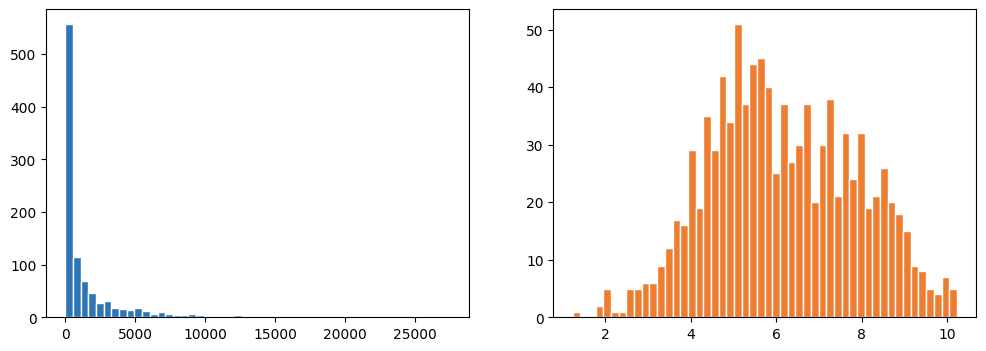

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['value_£'], bins=50, color='#2E75B6', edgecolor='white')
axes[1].hist(np.log1p(df['value_£']), bins=50, color='#ED7D31', edgecolor='white')
plt.savefig('fig1_distribution.png', bbox_inches='tight')

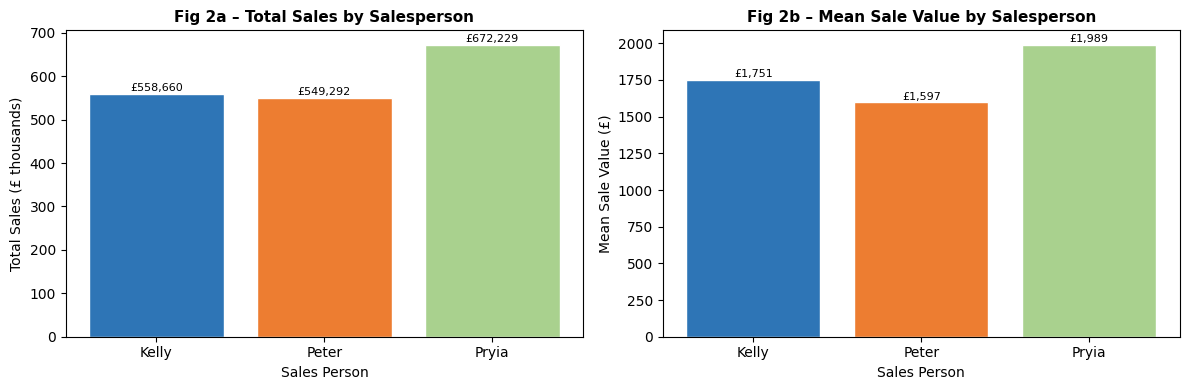

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PALETTE = ['#2E75B6', '#ED7D31', '#A9D18E']

# Calculate total and mean per salesperson
sp_stats = df.groupby('sales_person', observed=True)['value_£'].agg(
    total='sum', mean='mean').reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fig 2a — Total Sales by Salesperson
bars = axes[0].bar(sp_stats['sales_person'], sp_stats['total'] / 1000,
                   color=PALETTE, edgecolor='white')
for bar, val in zip(bars, sp_stats['total']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 2,
                 f'£{val:,.0f}',
                 ha='center', va='bottom', fontsize=8)
axes[0].set_title('Fig 2a – Total Sales by Salesperson',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Total Sales (£ thousands)')
axes[0].set_xlabel('Sales Person')

# Fig 2b — Mean Sale Value by Salesperson
bars2 = axes[1].bar(sp_stats['sales_person'], sp_stats['mean'],
                    color=PALETTE, edgecolor='white')
for bar, val in zip(bars2, sp_stats['mean']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 f'£{val:,.0f}',
                 ha='center', va='bottom', fontsize=8)
axes[1].set_title('Fig 2b – Mean Sale Value by Salesperson',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean Sale Value (£)')
axes[1].set_xlabel('Sales Person')

plt.tight_layout()
plt.savefig('fig2_salesperson.png', bbox_inches='tight')
plt.show()

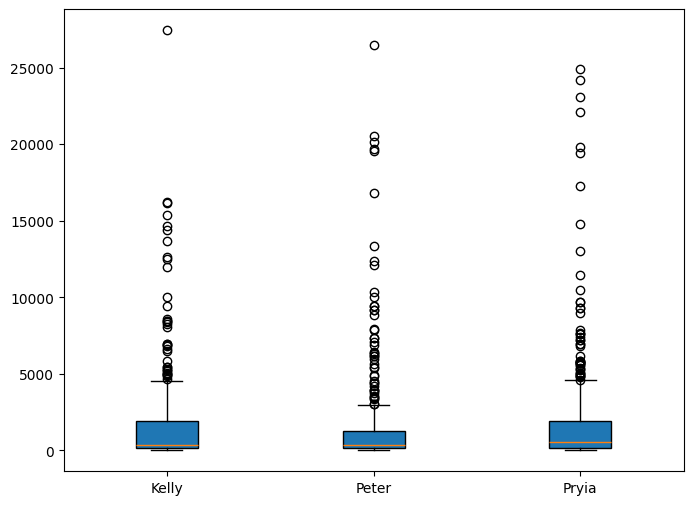

In [ ]:
# Boxplot
data_by_sp = [df[df['sales_person']==sp]['value_£'].values for sp in ['Kelly','Peter','Pryia']]
fig, ax = plt.subplots(1, 1, figsize=(8, 6)) # Create a new figure and axis for the boxplot
ax.boxplot(data_by_sp, tick_labels=['Kelly','Peter','Pryia'], patch_artist=True)
plt.savefig('fig3_boxplot.png', bbox_inches='tight')

In [ ]:
monthly_sales = df.groupby(['sales_person', 'month_year'], observed=True)['value_£'].sum().reset_index()
print(monthly_sales.head())

  sales_person month_year    value_£
0        Kelly    2020-06   55052.67
1        Kelly    2020-07  104374.60
2        Kelly    2020-08  109806.12
3        Kelly    2020-09  112121.18
4        Kelly    2020-10  108327.39


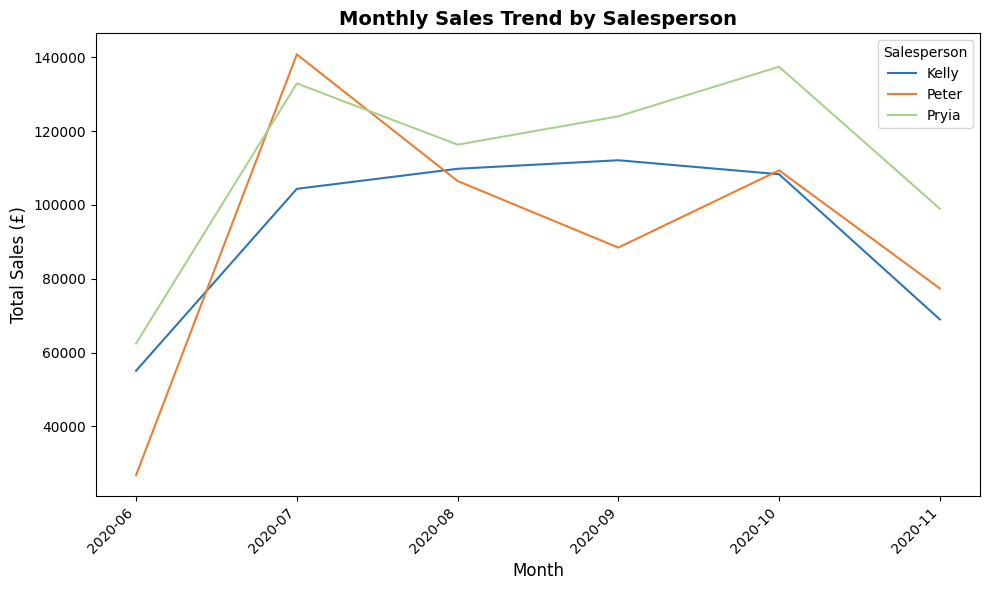

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Ensure month_year is in a plottable format (e.g., string or datetime)
monthly_sales['month_year_str'] = monthly_sales['month_year'].astype(str)

fig, ax = plt.subplots(figsize=(10, 6))

salespeople = monthly_sales['sales_person'].unique()

for i, sp in enumerate(salespeople):
    sp_data = monthly_sales[monthly_sales['sales_person'] == sp]
    ax.plot(sp_data['month_year_str'], sp_data['value_£'], label=sp, color=PALETTE[i])

ax.set_title('Monthly Sales Trend by Salesperson', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Sales (£)', fontsize=12)
ax.legend(title='Salesperson')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('fig_monthly_sales_trend.png', bbox_inches='tight')
plt.show()


In [ ]:
import seaborn as sns

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(pivot_df/1000, annot=True, fmt='.1f', cmap='Blues')
plt.title('Monthly Sales by Salesperson (£ thousands)', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Salesperson', fontsize=12)
plt.savefig('fig7_heatmap.png', bbox_inches='tight')
plt.show()

NameError: name 'pivot_df' is not defined

In [ ]:
priority_counts = df['priority'].value_counts()
print(priority_counts)

priority
Critical         221
Not Specified    213
Low              200
High             196
Medium           171
Name: count, dtype: int64


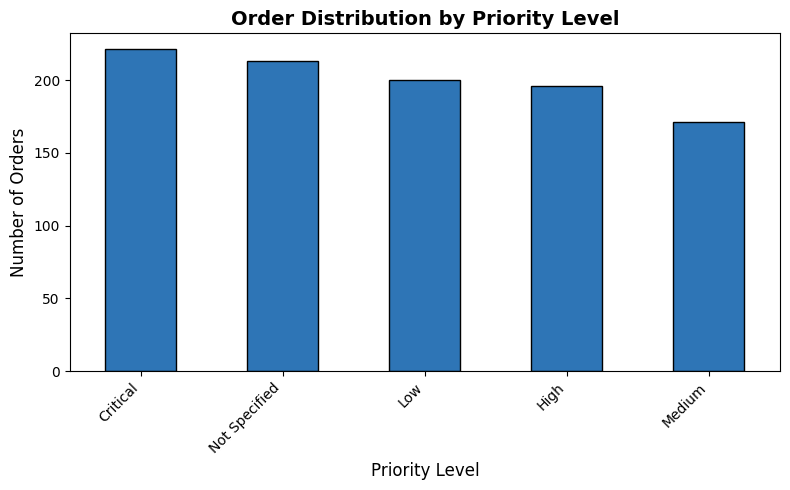

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
priority_counts.plot(kind='bar', color='#2E75B6', edgecolor='black')
plt.title('Order Distribution by Priority Level', fontsize=14, fontweight='bold')
plt.xlabel('Priority Level', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.savefig('fig_priority_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
mean_sales_by_priority = df.groupby('priority', observed=True)['value_£'].mean().reset_index()
print(mean_sales_by_priority)

        priority      value_£
0       Critical  1826.481131
1           High  1946.650000
2            Low  1462.679050
3         Medium  1931.797485
4  Not Specified  1747.003474


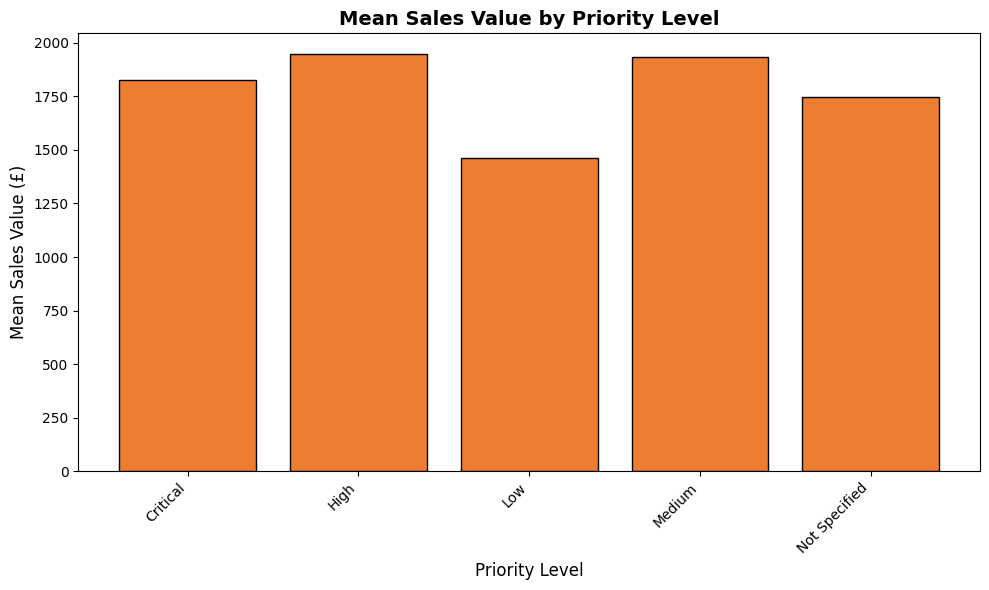

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(mean_sales_by_priority['priority'], mean_sales_by_priority['value_£'], color='#ED7D31', edgecolor='black')
plt.title('Mean Sales Value by Priority Level', fontsize=14, fontweight='bold')
plt.xlabel('Priority Level', fontsize=12)
plt.ylabel('Mean Sales Value (£)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_mean_sales_by_priority.png', bbox_inches='tight')
plt.show()

In [ ]:
import statsmodels.api as sm

y = df['value_£']
X = df['priority_num']

# Drop rows where either y or X has NaN values
data_for_ols = pd.DataFrame({'y': y, 'X': X}).dropna()
y = data_for_ols['y']
X = data_for_ols['X']

X = sm.add_constant(X) # Add a constant to the independent variable

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.085
Date:                Mon, 30 Mar 2026   Prob (F-statistic):              0.298
Time:                        11:02:19   Log-Likelihood:                -7522.4
No. Observations:                 788   AIC:                         1.505e+04
Df Residuals:                     786   BIC:                         1.506e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1616.2953    203.512      7.942      0.0

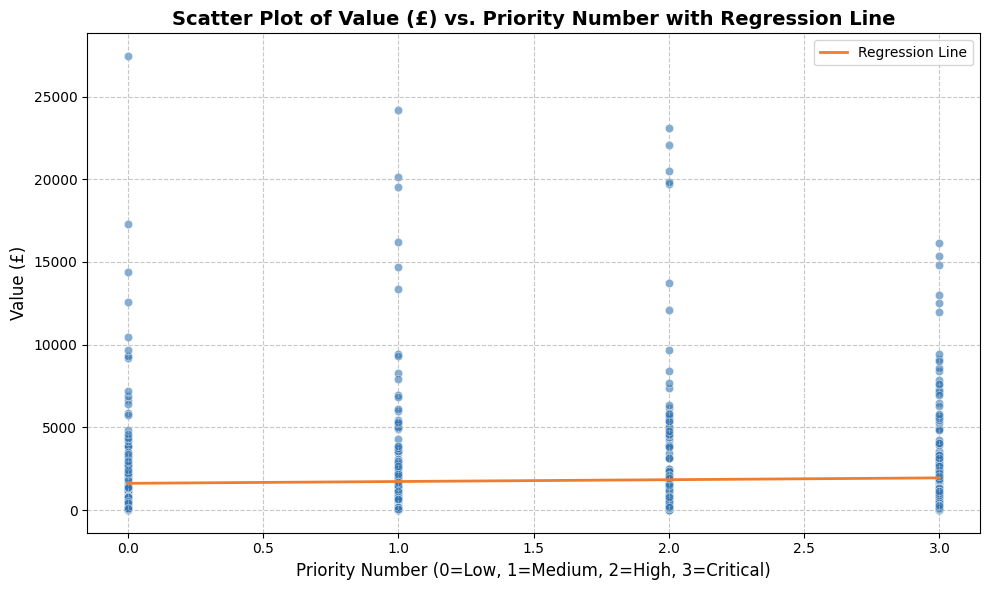

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get the regression line values
X_plot = np.linspace(X['X'].min(), X['X'].max(), 100)
y_plot = results.params.iloc[0] + results.params.iloc[1] * X_plot

plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_for_ols['X'], y=data_for_ols['y'], color='#2E75B6', alpha=0.6)
plt.plot(X_plot, y_plot, color='#ED7D31', linewidth=2, label='Regression Line')

plt.title('Scatter Plot of Value (£) vs. Priority Number with Regression Line', fontsize=14, fontweight='bold')
plt.xlabel('Priority Number (0=Low, 1=Medium, 2=High, 3=Critical)', fontsize=12)
plt.ylabel('Value (£)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('fig_regression_plot.png', bbox_inches='tight')
plt.show()

In [ ]:
sales_by_person_priority = df.groupby(['sales_person', 'priority'], observed=True)['value_£'].sum().reset_index()
pivot_df = sales_by_person_priority.pivot_table(index='sales_person', columns='priority', values='value_£', fill_value=0)
print(pivot_df.head())

priority       Critical       High        Low     Medium  Not Specified
sales_person                                                           
Kelly         144936.27   87798.01  106951.47  106487.29      112486.58
Peter          94964.12  121452.25   76504.18  125155.60      131215.91
Pryia         163751.94  172293.14  109080.16   98694.48      128409.25


/tmp/ipykernel_4739/504768813.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = sales_by_person_priority.pivot_table(index='sales_person', columns='priority', values='value_£', fill_value=0)


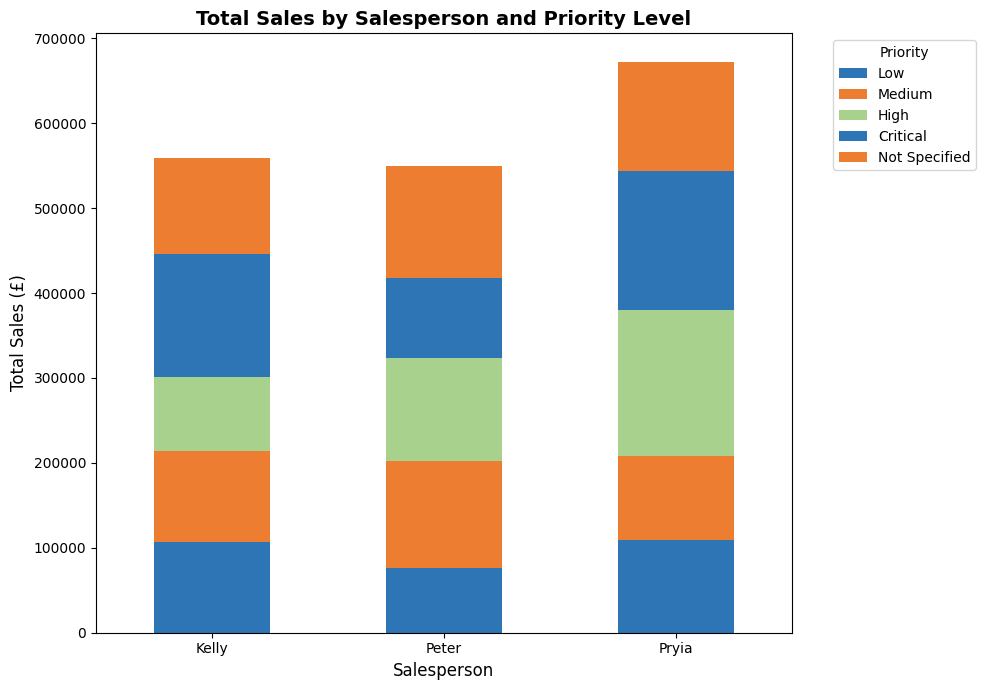

In [ ]:
import matplotlib.pyplot as plt

# Reorder columns to ensure consistent stacking order (optional, but good practice)
priority_order = ['Low', 'Medium', 'High', 'Critical', 'Not Specified']
pivot_df = pivot_df[priority_order]

pivot_df.plot(kind='bar', stacked=True, figsize=(10, 7), color=PALETTE)

plt.title('Total Sales by Salesperson and Priority Level', fontsize=14, fontweight='bold')
plt.xlabel('Salesperson', fontsize=12)
plt.ylabel('Total Sales (£)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Priority', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_stacked_sales_by_priority.png', bbox_inches='tight')
plt.show()


In [ ]:
from scipy import stats

sample = df['value_£'].dropna().sample(500, random_state=42)
stat, p = stats.shapiro(sample)
print(f'W = {stat:.4f}, p = {p:.6f}')

W = 0.4971, p = 0.000000


In [ ]:
df_corr = df[df['priority_num'].notna()].copy()

corr_s, p_s = stats.spearmanr(df_corr['priority_num'], df_corr['value_£'])
corr_p, p_p = stats.pearsonr(df_corr['priority_num'], df_corr['value_£'])

print(f'Spearman: r = {corr_s:.4f}, p = {p_s:.4f}')
print(f'Pearson:  r = {corr_p:.4f}, p = {p_p:.4f}')

Spearman: r = 0.0634, p = 0.0753
Pearson:  r = 0.0371, p = 0.2980


In [ ]:
groups = [df[df['sales_person']==sp]['value_£'].values
          for sp in ['Kelly', 'Peter', 'Pryia']]
h_stat, p_kw = stats.kruskal(*groups)
print(f'H = {h_stat:.4f}, p = {p_kw:.4f}')

H = 6.0269, p = 0.0491
